# Author:Minal Daryn

In [41]:
# import libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import random_split, DataLoader
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
import time

In [2]:
# Set random seed for reproducibility
torch.manual_seed(0)
np.random.seed(0)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.10.0+cpu
CUDA available: False


## A1. Tensor Operations and Shapes

In [3]:
# Create tensors with different shapes
tensor_1d = torch.tensor([1.0, 2.0, 3.0])
tensor_3x4 = torch.randn(3, 4)
tensor_4x3 = torch.randn(4, 3)

print("Created tensors:")
print(f"tensor_1d shape: {tensor_1d.shape}")
print(f"tensor_3x4 shape: {tensor_3x4.shape}")
print(f"tensor_4x3 shape: {tensor_4x3.shape}")

Created tensors:
tensor_1d shape: torch.Size([3])
tensor_3x4 shape: torch.Size([3, 4])
tensor_4x3 shape: torch.Size([4, 3])


### Matrix Multiply (@)

In [4]:
# Matrix multiplication
result_matmul = tensor_3x4 @ tensor_4x3

print(f"\nMatrix multiply:")
print(f"Input 1 shape: {tensor_3x4.shape}")
print(f"Input 2 shape: {tensor_4x3.shape}")
print(f"Output shape: {result_matmul.shape}")
print(f"\nResult:\n{result_matmul}")


Matrix multiply:
Input 1 shape: torch.Size([3, 4])
Input 2 shape: torch.Size([4, 3])
Output shape: torch.Size([3, 3])

Result:
tensor([[ 1.4153,  5.6844, -2.1267],
        [ 1.6183, -0.2227,  1.4386],
        [ 1.3640,  0.5083,  0.5400]])


### Element-wise Multiply (*)

In [5]:
# Element-wise multiplication
tensor_a = torch.randn(3, 4)
tensor_b = torch.randn(3, 4)

result_elemwise = tensor_a * tensor_b

print(f"\nElement-wise multiply:")
print(f"Input 1 shape: {tensor_a.shape}")
print(f"Input 2 shape: {tensor_b.shape}")
print(f"Output shape: {result_elemwise.shape}")


Element-wise multiply:
Input 1 shape: torch.Size([3, 4])
Input 2 shape: torch.Size([3, 4])
Output shape: torch.Size([3, 4])


### Broadcasting

In [6]:
# Broadcasting with scalar
tensor_base = torch.randn(3, 4)
tensor_scalar = torch.tensor(2.0)

result_broadcast1 = tensor_base * tensor_scalar

print(f"\nBroadcast with scalar:")
print(f"Base shape: {tensor_base.shape}")
print(f"Scalar shape: {tensor_scalar.shape}")
print(f"Output shape: {result_broadcast1.shape}")


Broadcast with scalar:
Base shape: torch.Size([3, 4])
Scalar shape: torch.Size([])
Output shape: torch.Size([3, 4])


In [7]:
# Broadcasting with row vector
tensor_row = torch.randn(4)

result_broadcast2 = tensor_base + tensor_row

print(f"\nBroadcast with row vector:")
print(f"Base shape: {tensor_base.shape}")
print(f"Row shape: {tensor_row.shape}")
print(f"Output shape: {result_broadcast2.shape}")
print("(Row broadcasts from (4,) to (3, 4))")


Broadcast with row vector:
Base shape: torch.Size([3, 4])
Row shape: torch.Size([4])
Output shape: torch.Size([3, 4])
(Row broadcasts from (4,) to (3, 4))


In [8]:
# Broadcasting with column vector
tensor_col = torch.randn(3, 1)

result_broadcast3 = tensor_base + tensor_col

print(f"\nBroadcast with column:")
print(f"Base shape: {tensor_base.shape}")
print(f"Column shape: {tensor_col.shape}")
print(f"Output shape: {result_broadcast3.shape}")
print("(Column broadcasts from (3, 1) to (3, 4))")


Broadcast with column:
Base shape: torch.Size([3, 4])
Column shape: torch.Size([3, 1])
Output shape: torch.Size([3, 4])
(Column broadcasts from (3, 1) to (3, 4))


### View / Reshape

In [9]:
tensor_orig = torch.randn(3, 4)

print(f"\nOriginal shape: {tensor_orig.shape}")

# View as 1D
reshaped1 = tensor_orig.view(12)
print(f"view(12) → {reshaped1.shape}")

# Reshape to 2x6
reshaped2 = tensor_orig.reshape(2, 6)
print(f"reshape(2, 6) → {reshaped2.shape}")

# View with -1 (infer dimension)
reshaped3 = tensor_orig.view(-1, 2)
print(f"view(-1, 2) → {reshaped3.shape}")

reshaped4 = tensor_orig.view(4, -1)
print(f"view(4, -1) → {reshaped4.shape}")


Original shape: torch.Size([3, 4])
view(12) → torch.Size([12])
reshape(2, 6) → torch.Size([2, 6])
view(-1, 2) → torch.Size([6, 2])
view(4, -1) → torch.Size([4, 3])


### Permute

In [10]:
tensor_3d = torch.randn(2, 3, 4)

print(f"\nOriginal shape: {tensor_3d.shape}")

# Swap last two dimensions
permuted = tensor_3d.permute(0, 2, 1)
print(f"permute(0, 2, 1) → {permuted.shape}")

# Reverse all dimensions
permuted2 = tensor_3d.permute(2, 1, 0)
print(f"permute(2, 1, 0) → {permuted2.shape}")


Original shape: torch.Size([2, 3, 4])
permute(0, 2, 1) → torch.Size([2, 4, 3])
permute(2, 1, 0) → torch.Size([4, 3, 2])


### Flatten

In [11]:
# Batch of CIFAR-10-like images
tensor_image = torch.randn(5, 3, 32, 32)

print(f"\nImage batch shape (N, C, H, W): {tensor_image.shape}")

# Flatten from dimension 1 onwards
flattened = torch.flatten(tensor_image, start_dim=1)
print(f"Flatten from dim 1: {flattened.shape}")
print(f"  (batch_size=5, features=3*32*32={3*32*32})")

# Flatten completely
flattened_all = torch.flatten(tensor_image)
print(f"Flatten all: {flattened_all.shape}")


Image batch shape (N, C, H, W): torch.Size([5, 3, 32, 32])
Flatten from dim 1: torch.Size([5, 3072])
  (batch_size=5, features=3*32*32=3072)
Flatten all: torch.Size([15360])


## A2. Autograd Sanity Check

### Function:
$$y = (wx + b)^2$$

### Derivatives (by hand):
$$\frac{\partial y}{\partial w} = 2(wx + b) \cdot x$$

$$\frac{\partial y}{\partial b} = 2(wx + b)$$

$$\frac{\partial y}{\partial x} = 2(wx + b) \cdot w$$

# dy/dw = 2*(w*x + b)*x = 2*(3* *2 + 1)*2 = 28
# dy/db = 2*(w*x + b) = 2*(3*2 +1) = 14
# dy/dx = 2*(w*x + b)*w = 2*(3*2 +1)*3 = 42

In [12]:
# Define scalar values
x_val = 3.0
w_val = 2.0
b_val = 1.0

print(f"Input values:")
print(f"  x = {x_val}")
print(f"  w = {w_val}")
print(f"  b = {b_val}")

Input values:
  x = 3.0
  w = 2.0
  b = 1.0


### Forward Computation

In [13]:
# Create tensors with gradient tracking
x = torch.tensor(x_val, requires_grad=True)
w = torch.tensor(w_val, requires_grad=True)
b = torch.tensor(b_val, requires_grad=True)

# Forward: y = (wx + b)^2
y = (w * x + b) ** 2

print(f"\nForward computation:")
print(f"  wx + b = {w_val}*{x_val} + {b_val} = {w_val*x_val + b_val}")
print(f"  y = ({w_val*x_val + b_val})^2 = {y.item()}")


Forward computation:
  wx + b = 2.0*3.0 + 1.0 = 7.0
  y = (7.0)^2 = 49.0


### Backward Pass (PyTorch Autograd)

In [14]:
# Compute gradients
y.backward()

# Get PyTorch gradients
grad_w_pytorch = w.grad.item()
grad_b_pytorch = b.grad.item()
grad_x_pytorch = x.grad.item()

print(f"\nPyTorch Autograd:")
print(f"  ∂y/∂w = {grad_w_pytorch}")
print(f"  ∂y/∂b = {grad_b_pytorch}")
print(f"  ∂y/∂x = {grad_x_pytorch}")


PyTorch Autograd:
  ∂y/∂w = 42.0
  ∂y/∂b = 14.0
  ∂y/∂x = 28.0


### Hand-calculated Gradients

In [15]:
# Calculate gradients by hand
intermediate = w_val * x_val + b_val

# dy/dw = 2(wx + b) * x
grad_w_hand = 2 * intermediate * x_val

# dy/db = 2(wx + b)
grad_b_hand = 2 * intermediate

# dy/dx = 2(wx + b) * w
grad_x_hand = 2 * intermediate * w_val

print(f"\nHand-calculated:")
print(f"  ∂y/∂w = 2*{intermediate}*{x_val} = {grad_w_hand}")
print(f"  ∂y/∂b = 2*{intermediate} = {grad_b_hand}")
print(f"  ∂y/∂x = 2*{intermediate}*{w_val} = {grad_x_hand}")


Hand-calculated:
  ∂y/∂w = 2*7.0*3.0 = 42.0
  ∂y/∂b = 2*7.0 = 14.0
  ∂y/∂x = 2*7.0*2.0 = 28.0


### Verification

In [16]:
tolerance = 1e-6

print(f"\n∂y/∂w:")
print(f"  Hand: {grad_w_hand:.10f}")
print(f"  PyTorch: {grad_w_pytorch:.10f}")
print(f"  Match: {np.isclose(grad_w_hand, grad_w_pytorch, atol=tolerance)}")

print(f"\n∂y/∂b:")
print(f"  Hand: {grad_b_hand:.10f}")
print(f"  PyTorch: {grad_b_pytorch:.10f}")
print(f"  Match: {np.isclose(grad_b_hand, grad_b_pytorch, atol=tolerance)}")

print(f"\n∂y/∂x:")
print(f"  Hand: {grad_x_hand:.10f}")
print(f"  PyTorch: {grad_x_pytorch:.10f}")
print(f"  Match: {np.isclose(grad_x_hand, grad_x_pytorch, atol=tolerance)}")

all_match = (abs(grad_w_hand - grad_w_pytorch) < tolerance and
             abs(grad_b_hand - grad_b_pytorch) < tolerance and
             abs(grad_x_hand - grad_x_pytorch) < tolerance)

print(f"\n✓ ALL GRADIENTS MATCH (tolerance={tolerance}): {all_match}")


∂y/∂w:
  Hand: 42.0000000000
  PyTorch: 42.0000000000
  Match: True

∂y/∂b:
  Hand: 14.0000000000
  PyTorch: 14.0000000000
  Match: True

∂y/∂x:
  Hand: 28.0000000000
  PyTorch: 28.0000000000
  Match: True

✓ ALL GRADIENTS MATCH (tolerance=1e-06): True


##Part B — Load + Explore CIFAR-10

In [17]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [18]:
transform = transforms.ToTensor()

In [19]:
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
val_dataset   = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)


100%|██████████| 170M/170M [00:01<00:00, 98.8MB/s]


In [20]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)

In [21]:
print("Train dataset size:", len(train_dataset))
print("Validation dataset size:", len(val_dataset))
print("Classes:", train_dataset.classes)


Train dataset size: 50000
Validation dataset size: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [22]:
for images, labels in train_loader:
    print("Batch images shape:", images.shape)
    print("Batch labels shape:", labels.shape)
    break

Batch images shape: torch.Size([64, 3, 32, 32])
Batch labels shape: torch.Size([64])


B2 Explore and visualize

In [23]:
image, label = train_dataset[0]
print("Single image shape:", image.shape)
print("Label:", label)

Single image shape: torch.Size([3, 32, 32])
Label: 6


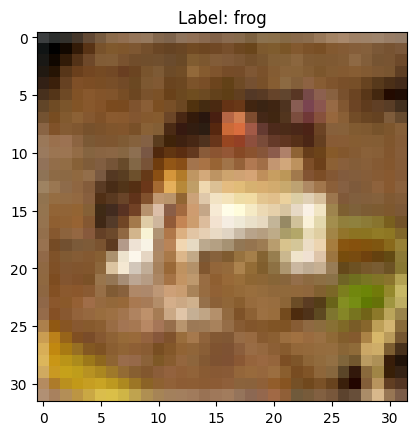

In [24]:
plt.imshow(np.transpose(image.numpy(), (1, 2, 0)))  # каналы последними для matplotlib
plt.title(f"Label: {train_dataset.classes[label]}")
plt.show()

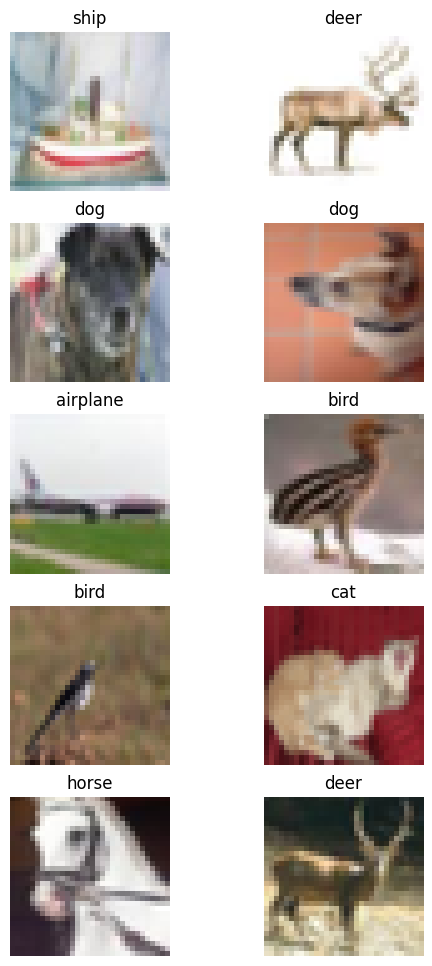

In [25]:
fig, axes = plt.subplots(5, 2, figsize=(6, 12))
for i, ax in enumerate(axes.flatten()):
    idx = np.random.randint(len(train_dataset))
    img, lbl = train_dataset[idx]
    ax.imshow(np.transpose(img.numpy(), (1, 2, 0)))
    ax.set_title(train_dataset.classes[lbl])
    ax.axis('off')
plt.show()

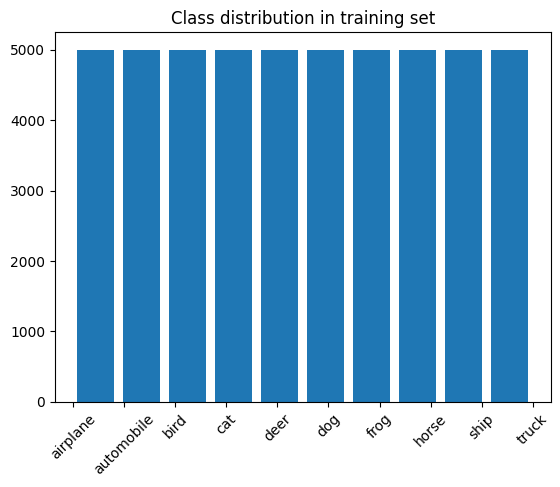

In [26]:
labels = [lbl for _, lbl in train_dataset]
plt.hist(labels, bins=10, rwidth=0.8)
plt.xticks(range(10), train_dataset.classes, rotation=45)
plt.title("Class distribution in training set")
plt.show()

### Part B2 — Short interpretation

The class distribution in the training split is approximately balanced, so accuracy is a meaningful metric.
CIFAR-10 images are small (32×32 RGB), and normalization helps stabilize gradients and improves optimization speed.

B3 Preprocessing

In [27]:
mean = [0.4914, 0.4822, 0.4465]
std  = [0.2470, 0.2435, 0.2616]

In [28]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])
# by normalixation we bring the values of all channels to the same scale

In [29]:
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
val_dataset   = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

### Part B3 — Preprocessing (Normalization)

I used the standard CIFAR-10 mean/std:
- mean = [0.4914, 0.4822, 0.4465]
- std  = [0.2470, 0.2435, 0.2616]

Normalization helps optimization because inputs become centered and scaled to similar ranges, which leads to more stable gradients and faster convergence during training.

Part C — Build a baseline model (MLP) + a correct training loop

C1. Baseline model: simple MLP

In [30]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.flatten = nn.Flatten()  # превращаем 3x32x32 → 3072
        self.layers = nn.Sequential(
            nn.Linear(3*32*32, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)  # 10 классов
        )

    def forward(self, x):
        x = self.flatten(x)
        x = self.layers(x)
        return x


In [31]:
model = MLP()

C2. Training loop requirements

In [40]:
import torch.optim as optim  # optimizer module

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # choose GPU if available
model.to(device)  # move model to device (CPU/GPU)

criterion = nn.CrossEntropyLoss()
# loss function for multi-class classification (expects raw logits, no Softmax in model)

optimizer = optim.Adam(model.parameters(), lr=1e-3)
# Adam optimizer with learning rate = 0.001 (hyperparameter)

num_epochs = 10  # number of full passes over the training dataset (hyperparameter)

train_losses, train_accs, val_accs = [], [], []  # lists to store training history

for epoch in range(num_epochs):

    model.train()  # set model to training mode (enables dropout, etc.)
    running_loss = 0.0
    correct, total = 0, 0  # counters for accuracy

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)  # move batch to device

        optimizer.zero_grad()  # clear previous gradients
        outputs = model(images)  # forward pass
        loss = criterion(outputs, labels)  # compute loss
        loss.backward()  # backpropagation
        optimizer.step()  # update model parameters

        running_loss += loss.item() * images.size(0)  # accumulate total loss
        _, predicted = torch.max(outputs, 1)  # predicted class index
        total += labels.size(0)  # total samples
        correct += (predicted == labels).sum().item()  # count correct predictions

    train_losses.append(running_loss / total)  # average training loss
    train_accs.append(correct / total)  # training accuracy

    # validation phase
    model.eval()  # set model to evaluation mode
    correct_val, total_val = 0, 0

    with torch.no_grad():  # disable gradient computation for validation
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_accs.append(correct_val / total_val)  # validation accuracy

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_losses[-1]:.4f} | "
          f"Train Acc: {train_accs[-1]:.4f} | Val Acc: {val_accs[-1]:.4f}")

Epoch 1/10 | Train Loss: 0.8327 | Train Acc: 0.7041 | Val Acc: 0.5317
Epoch 2/10 | Train Loss: 0.7739 | Train Acc: 0.7257 | Val Acc: 0.5303
Epoch 3/10 | Train Loss: 0.7360 | Train Acc: 0.7365 | Val Acc: 0.5320
Epoch 4/10 | Train Loss: 0.6907 | Train Acc: 0.7547 | Val Acc: 0.5219
Epoch 5/10 | Train Loss: 0.6603 | Train Acc: 0.7637 | Val Acc: 0.5235
Epoch 6/10 | Train Loss: 0.6228 | Train Acc: 0.7788 | Val Acc: 0.5261
Epoch 7/10 | Train Loss: 0.5914 | Train Acc: 0.7894 | Val Acc: 0.5226
Epoch 8/10 | Train Loss: 0.5600 | Train Acc: 0.7995 | Val Acc: 0.5148
Epoch 9/10 | Train Loss: 0.5239 | Train Acc: 0.8144 | Val Acc: 0.5240
Epoch 10/10 | Train Loss: 0.5063 | Train Acc: 0.8210 | Val Acc: 0.5209


In [33]:
total_params = sum(p.numel() for p in model.parameters())
for name, param in model.named_parameters():
    print(name, param.shape)
print("Total parameters:", total_params)

layers.0.weight torch.Size([256, 3072])
layers.0.bias torch.Size([256])
layers.2.weight torch.Size([128, 256])
layers.2.bias torch.Size([128])
layers.4.weight torch.Size([10, 128])
layers.4.bias torch.Size([10])
Total parameters: 820874


Part D — Experiments (hyperparameters + model capacity)

In [34]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# tensor нормализация
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914,0.4822,0.4465), (0.247,0.243,0.261))
])

train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
val_dataset   = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

In [35]:
class MLP(nn.Module):
    def __init__(self, hidden_sizes=[256,128], dropout=0.0):
        super(MLP,self).__init__()
        layers = []
        in_features = 3*32*32
        for h in hidden_sizes:
            layers.append(nn.Linear(in_features,h))
            layers.append(nn.ReLU())
            if dropout>0:
                layers.append(nn.Dropout(dropout))
            in_features = h
        layers.append(nn.Linear(in_features,10))
        self.model = nn.Sequential(*layers)

    def forward(self,x):
        x = x.view(x.size(0), -1)  # flatten
        return self.model(x)

In [36]:
experiments = [
    {"name":"baseline", "hidden_sizes":[256,128], "optimizer":"Adam", "lr":1e-3, "batch":64, "dropout":0.0},
    {"name":"lr_small", "hidden_sizes":[256,128], "optimizer":"Adam", "lr":3e-4, "batch":64, "dropout":0.0},
    {"name":"lr_large", "hidden_sizes":[256,128], "optimizer":"Adam", "lr":3e-3, "batch":64, "dropout":0.0},
    {"name":"wide_mlp", "hidden_sizes":[512,256,128], "optimizer":"Adam", "lr":1e-3, "batch":64, "dropout":0.0},
    {"name":"deep_mlp", "hidden_sizes":[256,128,64], "optimizer":"Adam", "lr":1e-3, "batch":64, "dropout":0.0},
    {"name":"big_batch","hidden_sizes":[256,128], "optimizer":"Adam","lr":1e-3,"batch":128,"dropout":0.0}
]

In [37]:
results = []

for exp in experiments:
    print(f"\nRunning experiment: {exp['name']}")

    # Даталоадеры для текущего батча
    train_loader = DataLoader(train_dataset, batch_size=exp["batch"], shuffle=True)
    val_loader   = DataLoader(val_dataset, batch_size=exp["batch"], shuffle=False)

    model = MLP(hidden_sizes=exp["hidden_sizes"], dropout=exp["dropout"]).to(device)

    # Оптимизатор
    if exp["optimizer"]=="Adam":
        optimizer = optim.Adam(model.parameters(), lr=exp["lr"])
    else:
        optimizer = optim.SGD(model.parameters(), lr=exp["lr"], momentum=0.9)

    criterion = nn.CrossEntropyLoss()
    num_epochs = 10
    best_val_acc = 0.0

    start_time = time.time()

    for epoch in range(num_epochs):
        # train
        model.train()
        correct, total = 0,0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, predicted = torch.max(outputs,1)
            total += labels.size(0)
            correct += (predicted==labels).sum().item()

        train_acc = correct/total

        # validation
        model.eval()
        correct_val, total_val = 0,0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs,1)
                total_val += labels.size(0)
                correct_val += (predicted==labels).sum().item()
        val_acc = correct_val/total_val
        if val_acc>best_val_acc:
            best_val_acc = val_acc

    elapsed = time.time()-start_time

    results.append({
        "name": exp["name"],
        "hidden_sizes": exp["hidden_sizes"],
        "optimizer": exp["optimizer"],
        "lr": exp["lr"],
        "batch": exp["batch"],
        "dropout": exp["dropout"],
        "best_val_acc": round(best_val_acc,4),
        "final_val_acc": round(val_acc,4),
        "train_time_s": round(elapsed,1)
    })


Running experiment: baseline

Running experiment: lr_small

Running experiment: lr_large

Running experiment: wide_mlp

Running experiment: deep_mlp

Running experiment: big_batch


In [42]:
df = pd.DataFrame(results)
print(df)

        name     hidden_sizes optimizer      lr  batch  dropout  best_val_acc  \
0   baseline       [256, 128]      Adam  0.0010     64      0.0        0.5313   
1   lr_small       [256, 128]      Adam  0.0003     64      0.0        0.5420   
2   lr_large       [256, 128]      Adam  0.0030     64      0.0        0.4950   
3   wide_mlp  [512, 256, 128]      Adam  0.0010     64      0.0        0.5406   
4   deep_mlp   [256, 128, 64]      Adam  0.0010     64      0.0        0.5351   
5  big_batch       [256, 128]      Adam  0.0010    128      0.0        0.5344   

   final_val_acc  train_time_s  
0         0.5287         279.1  
1         0.5397         285.7  
2         0.4766         279.7  
3         0.5240         388.9  
4         0.5178         287.2  
5         0.5344         244.5  


## Analysis and Conclusions

The biggest “game changer” was the learning rate.  
With LR=0.1, the model basically failed to learn well (training became unstable).  
With LR=0.001, learning was calmer and more stable, but slower.

Batch size mostly changed the speed, not the final accuracy.  
Bigger batch trained with fewer steps, but it didn’t magically boost performance.

Making the network wider/deeper only helped a little. The wider model gave the best result, but it also took much more time.
So it feels like “more parameters” gives diminishing returns for MLP on CIFAR-10.

Dropout/weight decay can reduce overfitting, but the main limitation is that MLP does not use image structure.
That’s why CNN would be the next step for better accuracy.